# Tiny ImageNet — standalone data pipeline audit

**No CNN, optimizer, or training.** Run from project root; adjust `TINY_ROOT` if necessary. Checks sizes, mapping, split duplicates, normalization and visual samples.

In [1]:
from pathlib import Path
import hashlib
import numpy as np
import torch
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from src.dataset._balance_class_subset import BalancedClassSubset
from src.dataset.tiny_imagenet_dataset_2 import TinyImageNetLoader, test_transform, means, stds, get_tiny_imagenet_class_names
SEED=42
NUM_CLASSES=200
TRAIN_PER_CLASS=450
VAL_PER_CLASS=100
TINY_ROOT=Path('../data/tiny_imagenet/tiny-imagenet-200-450train-100val')
assert TINY_ROOT.exists(), f'Dataset root missing: {TINY_ROOT}'


## 1. Load deterministic clean train and validation datasets (no augmentation)

In [2]:
train_ds, val_ds, _, _ = TinyImageNetLoader(seed=SEED, root=TINY_ROOT, train_transform=test_transform).load()
train_ds.transform = test_transform
if hasattr(val_ds, 'transform'): val_ds.transform = test_transform
selected=list(range(NUM_CLASSES))
train=BalancedClassSubset(train_ds,selected,TRAIN_PER_CLASS,seed=SEED)
val=BalancedClassSubset(val_ds,selected,VAL_PER_CLASS,seed=SEED+1)
CLASS_NAMES=get_tiny_imagenet_class_names(train_ds,TINY_ROOT)
print('Train:',len(train),'Validation:',len(val))


Tiny ImageNet loaded
Classes: 200
Train images: 90000
Validation images: 20000
Test images: 10000
Train: 90000 Validation: 20000


## 2. Sizes, class balance, label mapping and underlying indices

In [5]:
def labels_for(subset):
    # Current BalancedClassSubset stores (dataset_index, remapped_label) tuples.
    return np.asarray([new_label for dataset_index, new_label in subset.samples], dtype=np.int64)

train_y = labels_for(train)
val_y = labels_for(val)

# Independently verify saved labels against the underlying dataset metadata.
def verify_mapping(subset):
    original_labels = BalancedClassSubset._get_labels(subset.dataset)
    mismatches = [
        (dataset_index, new_label, original_labels[dataset_index])
        for dataset_index, new_label in subset.samples
        if subset.original_to_new[int(original_labels[dataset_index])] != new_label
    ]
    return mismatches

train_mismatches = verify_mapping(train)
val_mismatches = verify_mapping(val)
checks = {
    'train count': len(train) == NUM_CLASSES * TRAIN_PER_CLASS,
    'val count': len(val) == NUM_CLASSES * VAL_PER_CLASS,
    'train class balance': np.all(np.bincount(train_y, minlength=NUM_CLASSES) == TRAIN_PER_CLASS),
    'val class balance': np.all(np.bincount(val_y, minlength=NUM_CLASSES) == VAL_PER_CLASS),
    'same numeric class mapping': train.original_to_new == val.original_to_new,
    'train labels match source metadata': not train_mismatches,
    'val labels match source metadata': not val_mismatches,
    'unique train indices': len({i for i, _ in train.samples}) == len(train.samples),
    'unique val indices': len({i for i, _ in val.samples}) == len(val.samples),
    'class names available': len(CLASS_NAMES) >= NUM_CLASSES,
}
for name, ok in checks.items():
    print(('PASS' if ok else 'FAIL'), name)
assert all(checks.values()), 'Review failed checks above'
if train.dataset is val.dataset:
    overlap = {i for i, _ in train.samples} & {i for i, _ in val.samples}
    print('Shared underlying indices:', len(overlap))
    assert not overlap, 'Train/validation index overlap!'
else:
    print('Separate underlying datasets: compare image content below; indices alone are not comparable.')


PASS train count
PASS val count
PASS train class balance
PASS val class balance
PASS same numeric class mapping
PASS train labels match source metadata
PASS val labels match source metadata
PASS unique train indices
PASS unique val indices
PASS class names available
Separate underlying datasets: compare image content below; indices alone are not comparable.


## 3. Deterministic image-content duplicate scan

Hashes reconstructed 64×64 RGB pixels from the deterministic test transform. Detects exact matching pixel content; not near duplicates. Full scan of 110,000 images may take several minutes. No training.

In [ ]:
mean=torch.as_tensor(means,dtype=torch.float32).view(3,1,1)
std=torch.as_tensor(stds,dtype=torch.float32).view(3,1,1)
assert torch.isfinite(mean).all() and torch.isfinite(std).all() and (std>0).all()
def fingerprint(subset,name):
    hashes=[]
    for i in tqdm(range(len(subset)),desc=name):
        x,y=subset[i]
        if not isinstance(x,torch.Tensor) or x.shape!=(3,64,64) or not torch.isfinite(x).all():
            raise ValueError(f'Invalid image at index {i}: {getattr(x,"shape",None)}')
        rgb=((x.float().cpu()*std+mean).clamp(0,1)*255).round().byte()
        hashes.append(hashlib.sha256(rgb.numpy().tobytes()).hexdigest())
    return hashes
train_hashes=fingerprint(train,'Hash train')
val_hashes=fingerprint(val,'Hash val')
train_set,val_set=set(train_hashes),set(val_hashes)
overlap=train_set&val_set
print('Unique train images:',len(train_set),'/',len(train_hashes))
print('Unique val images:',len(val_set),'/',len(val_hashes))
print('Identical images in both splits:',len(overlap))
print('PASS: no exact duplicate pixels across splits' if not overlap else 'WARNING: cross-split duplicates found!')


## 4. Normalization and image inspection

Check `test_transform` visually to confirm it uses the same means/stds printed below. Review whether displayed images match their class labels.

In [ ]:
print('Test transform:',test_transform)
print('Means:',means,'Stds:',stds)
rng=np.random.default_rng(SEED)
ix=rng.choice(len(train),size=min(256,len(train)),replace=False)
xs=torch.stack([train[int(i)][0] for i in ix])
raw=(xs*std+mean).clamp(0,1)
print('Normalized channel means:',xs.mean((0,2,3)).numpy().round(4))
print('Decoded channel means:',raw.mean((0,2,3)).numpy().round(4))
print('Decoded min/max:',float(raw.min()),float(raw.max()))
assert torch.isfinite(xs).all()
fig,axs=plt.subplots(6,4,figsize=(12,15))
for row in range(6):
    cls=int(rng.integers(NUM_CLASSES))
    for col,(ds,ys,name) in enumerate([(train,train_y,'Train'),(train,train_y,'Train'),(val,val_y,'Val'),(val,val_y,'Val')]):
        idx=int(rng.choice(np.flatnonzero(ys==cls)))
        x,y=ds[idx]
        im=(x*std+mean).clamp(0,1).permute(1,2,0)
        axs[row,col].imshow(im)
        axs[row,col].set_title(f'{name}: {CLASS_NAMES[cls]}',fontsize=9)
        axs[row,col].axis('off')
plt.tight_layout();plt.show()


**Interpretation:** PASS confirms internal numeric mapping and class counts, not semantic correctness of every label. Zero matching hashes excludes exact duplicate 64×64 RGB pixels under this transform, not near-duplicates or all forms of leakage. This notebook never trains a model.

Clean train:   0%|          | 0/90000 [00:00<?, ?it/s]

Validation:   0%|          | 0/20000 [00:00<?, ?it/s]

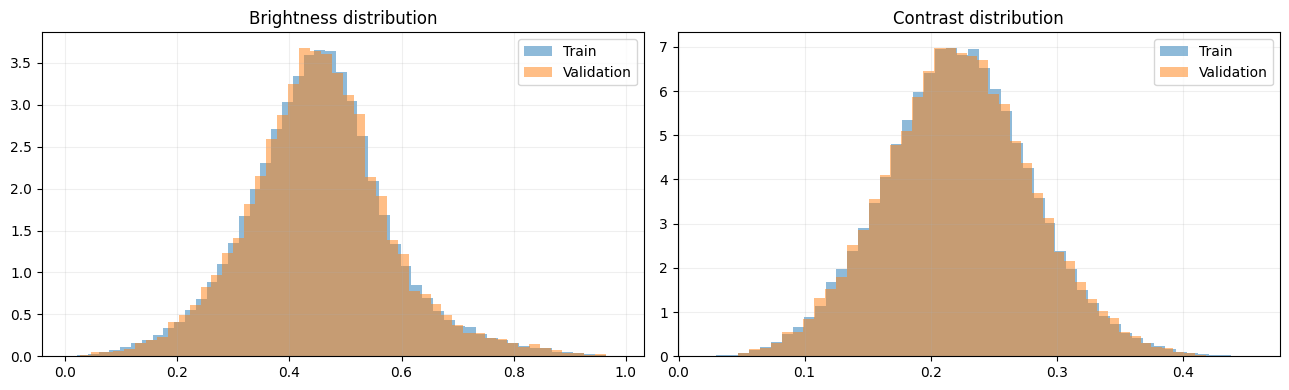


BRIGHTNESS
Train mean: 0.45193756007034747
Val mean:   0.4526196568757296

CONTRAST
Train mean: 0.22205746403495885
Val mean:   0.2222187126529403

RGB channel means
Train: [0.48032692 0.44804853 0.39750162]
Val:   [0.48089194 0.44886503 0.39780158]


In [3]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

mean = torch.tensor(means).view(3, 1, 1)
std = torch.tensor(stds).view(3, 1, 1)

def get_image_stats(dataset, name):
    brightness = []
    contrast = []
    channel_means = []

    for i in tqdm(range(len(dataset)), desc=name):
        x, _ = dataset[i]

        # Undo normalization
        rgb = (x.cpu() * std + mean).clamp(0, 1)

        gray = (
            0.299 * rgb[0] +
            0.587 * rgb[1] +
            0.114 * rgb[2]
        )

        brightness.append(gray.mean().item())
        contrast.append(gray.std().item())
        channel_means.append(rgb.mean(dim=(1, 2)).numpy())

    return {
        "brightness": np.array(brightness),
        "contrast": np.array(contrast),
        "channel_means": np.stack(channel_means)
    }

train_stats = get_image_stats(train, "Clean train")
val_stats = get_image_stats(val, "Validation")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, metric, title in zip(
    axes,
    ["brightness", "contrast"],
    ["Brightness distribution", "Contrast distribution"]
):
    ax.hist(train_stats[metric], bins=50, density=True,
            alpha=0.5, label="Train")
    ax.hist(val_stats[metric], bins=50, density=True,
            alpha=0.5, label="Validation")
    ax.set_title(title)
    ax.legend()
    ax.grid(alpha=0.2)

plt.tight_layout()
plt.show()

for metric in ["brightness", "contrast"]:
    print(f"\n{metric.upper()}")
    print("Train mean:", train_stats[metric].mean())
    print("Val mean:  ", val_stats[metric].mean())

print("\nRGB channel means")
print("Train:", train_stats["channel_means"].mean(axis=0))
print("Val:  ", val_stats["channel_means"].mean(axis=0))

Train blur:   0%|          | 0/5000 [00:00<?, ?it/s]

Validation blur:   0%|          | 0/5000 [00:00<?, ?it/s]

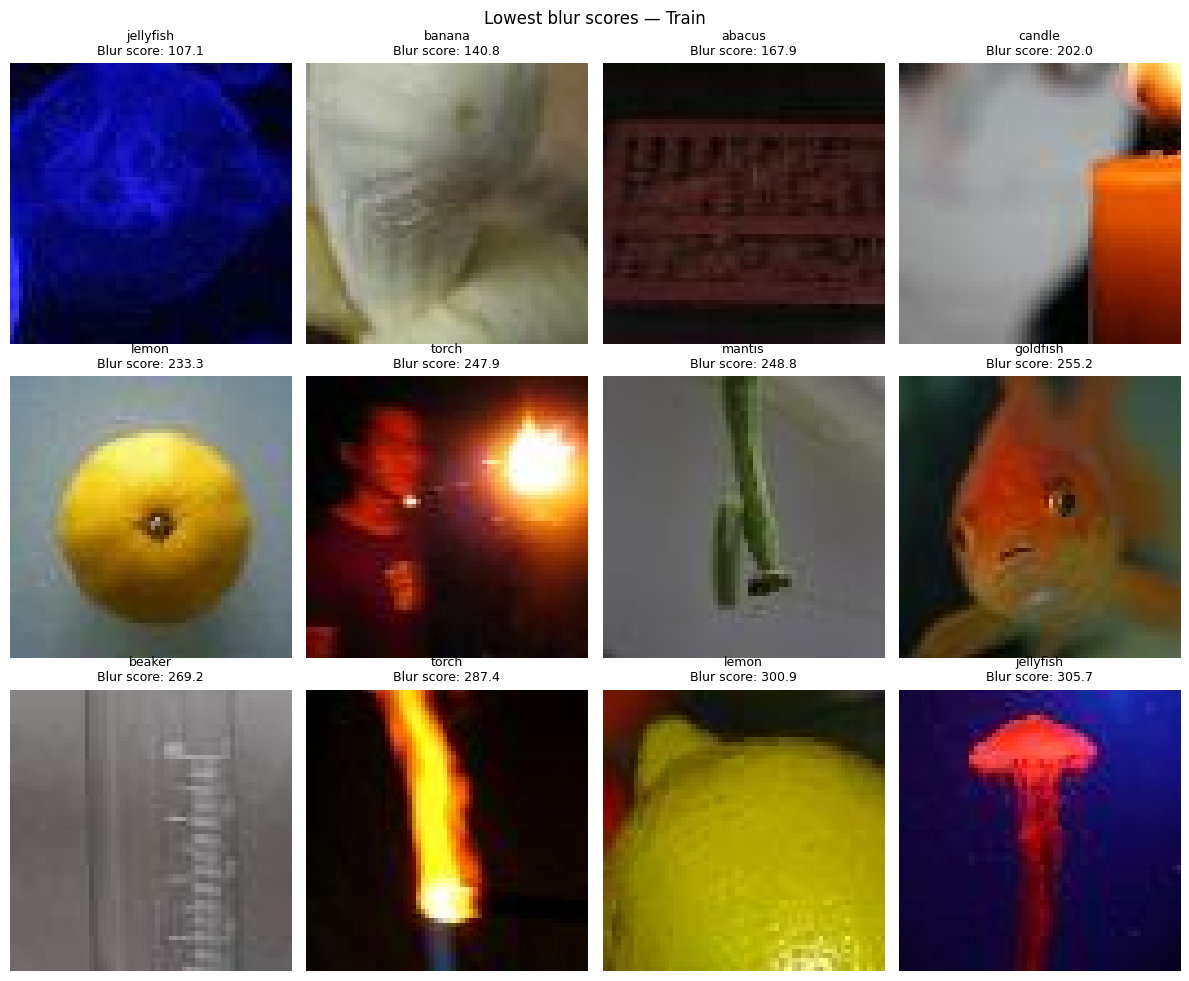

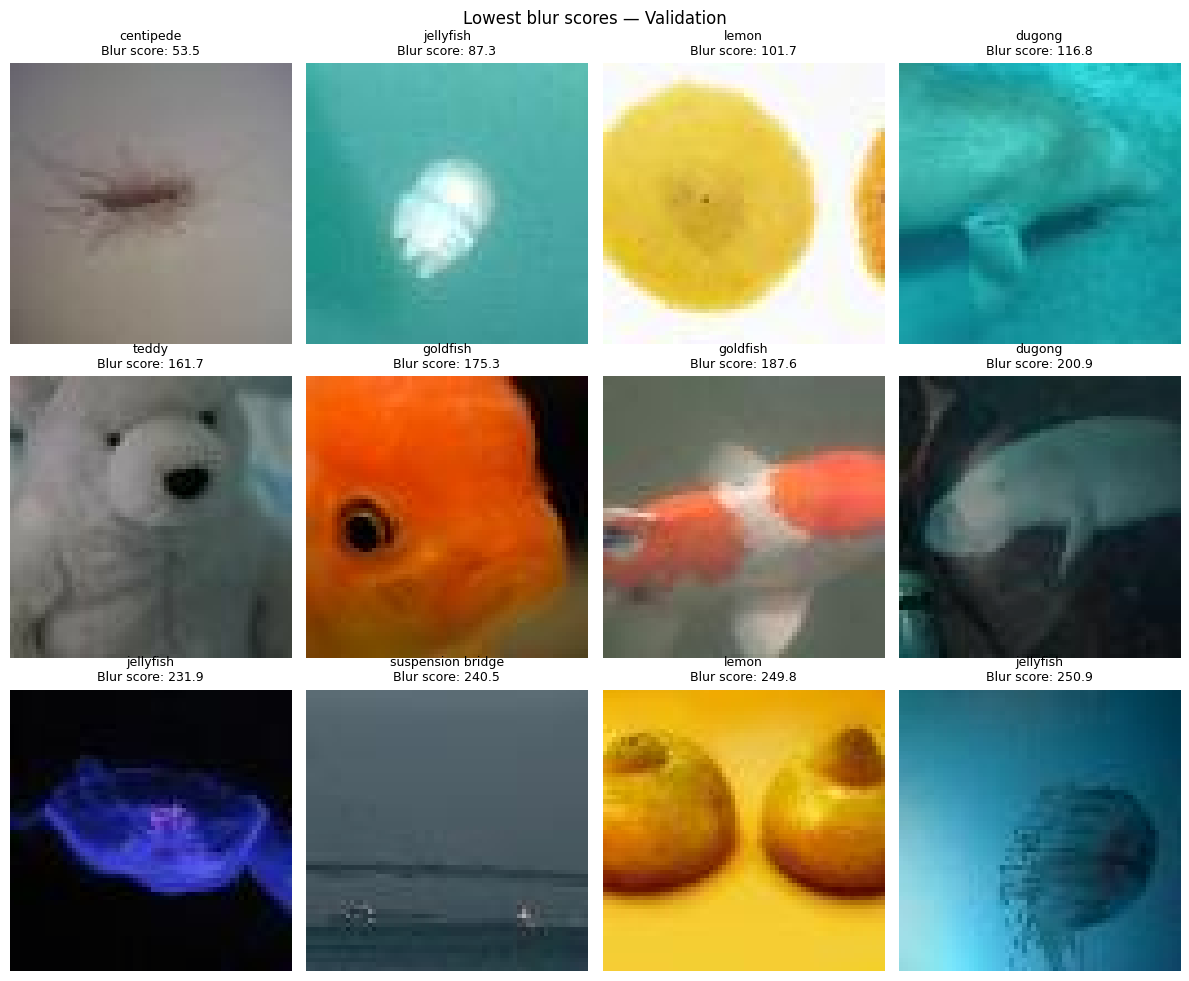

Train median blur score: 7700.53157171607
Val median blur score: 7794.13998362422


In [6]:
import cv2

def blur_analysis(dataset, labels, name, sample_size=5000):
    rng = np.random.default_rng(SEED)
    indices = rng.choice(
        len(dataset),
        size=min(sample_size, len(dataset)),
        replace=False
    )

    results = []

    for i in tqdm(indices, desc=name):
        x, _ = dataset[int(i)]

        rgb = (x.cpu() * std + mean).clamp(0, 1)
        image = (
            rgb.permute(1, 2, 0).numpy() * 255
        ).astype(np.uint8)

        gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
        blur_score = cv2.Laplacian(
            gray, cv2.CV_64F
        ).var()

        results.append((
            int(i),
            int(labels[i]),
            blur_score
        ))

    return sorted(results, key=lambda x: x[2])

train_blur = blur_analysis(train, train_y, "Train blur")
val_blur = blur_analysis(val, val_y, "Validation blur")

def show_blurry(dataset, results, title, n=12):
    fig, axes = plt.subplots(3, 4, figsize=(12, 10))

    for ax, (idx, label, score) in zip(
        axes.flat, results[:n]
    ):
        x, _ = dataset[idx]
        rgb = (x.cpu() * std + mean).clamp(0, 1)

        ax.imshow(rgb.permute(1, 2, 0))
        ax.set_title(
            f"{CLASS_NAMES[label]}\nBlur score: {score:.1f}",
            fontsize=9
        )
        ax.axis("off")

    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

show_blurry(train, train_blur, "Lowest blur scores — Train")
show_blurry(val, val_blur, "Lowest blur scores — Validation")

print("Train median blur score:",
      np.median([r[2] for r in train_blur]))
print("Val median blur score:",
      np.median([r[2] for r in val_blur]))

In [10]:
from torchvision import transforms
import numpy as np
from src.dataset.tiny_imagenet_dataset_2 import convert_to_rgb

training_transform = transforms.Compose([
    transforms.Lambda(convert_to_rgb),
    transforms.RandomCrop(64, padding=4, padding_mode="reflect"),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandAugment(num_ops=2, magnitude=7),
    transforms.ToTensor(),
    transforms.Normalize(mean=means, std=stds),
])

print("TRAINING TRANSFORM")
print(training_transform)

print("\nVALIDATION TRANSFORM")
print(test_transform)

# Check expected training augmentations
for op in (
    transforms.RandomCrop,
    transforms.RandomHorizontalFlip,
    transforms.RandAugment,
):
    assert any(
        isinstance(t, op)
        for t in training_transform.transforms
    ), f"Missing: {op.__name__}"

# Check validation contains no random augmentation
assert not any(
    isinstance(t, (
        transforms.RandomCrop,
        transforms.RandomHorizontalFlip,
        transforms.RandomVerticalFlip,
        transforms.RandAugment,
        transforms.RandomRotation,
        transforms.RandomResizedCrop,
    ))
    for t in test_transform.transforms
)

# Check normalization
def get_normalize(transform):
    return next(
        t for t in transform.transforms
        if isinstance(t, transforms.Normalize)
    )

a = get_normalize(training_transform)
b = get_normalize(test_transform)

assert np.allclose(a.mean, b.mean)
assert np.allclose(a.std, b.std)

print("\nPASS: Expected augmentation configuration")
print("PASS: Validation has no listed random augmentation")
print("PASS: Normalization matches")

TRAINING TRANSFORM
Compose(
    Lambda()
    RandomCrop(size=(64, 64), padding=4)
    RandomHorizontalFlip(p=0.5)
    RandAugment(num_ops=2, magnitude=7, num_magnitude_bins=31, interpolation=InterpolationMode.NEAREST, fill=None)
    ToTensor()
    Normalize(mean=[0.4803270399570465, 0.44804883003234863, 0.3975021243095398], std=[0.27645865082740784, 0.26883983612060547, 0.28148162364959717])
)

VALIDATION TRANSFORM
Compose(
    Lambda()
    ToTensor()
    Normalize(mean=[0.4803270399570465, 0.44804883003234863, 0.3975021243095398], std=[0.27645865082740784, 0.26883983612060547, 0.28148162364959717])
)

PASS: Expected augmentation configuration
PASS: Validation has no listed random augmentation
PASS: Normalization matches


In [28]:
from tqdm.notebook import tqdm

pbar = tqdm(range(1, 50), desc="Epoch", leave=True)
pbar.container.children[1].layout.height = "20px"

for epoch in pbar:
    pass

Epoch:   0%|          | 0/49 [00:00<?, ?it/s]